# Decomposition

## Global Importation

In [1]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

ERROR 1: PROJ: proj_create_from_database: Open of /apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/share/proj failed


## Global Inset

### Load Decomposition Results

In [2]:
path_decomp_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Decomposition'
filename = 'time_merged.nc'

save_names = ['swl2p0_decomposition_results', 'swl3p0_decomposition_results', 'swl4p0_decomposition_results',
              'swl5p0_decomposition_results', 'swl6p0_decomposition_results']

names = ['2-degree warming', '3-degree warming', '4-degree warming', '5-degree warming', '6-degree warming']
decomposed_compiled_results = {scenario: {} for scenario in names}

for file, scenario in zip(tqdm(save_names), names): 
    results_open = xr.open_dataset(f"{path_decomp_files}/{file}.nc")
    decomposed_compiled_results[scenario] = results_open

100%|███████████████████████████████████████████| 5/5 [00:01<00:00,  3.22it/s]


### Standardise Coordinates

In [3]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

## Processing Inset

### Define Boxes

In [4]:
import shapely.geometry as sgeom

def lon360_to_180(lon):
    return ((lon + 180) % 360) - 180

# Define box limits.
# Decomposition Boxing
# This box requires masking.
decomp_lon_min, decomp_lon_max = lon360_to_180(340.0), lon360_to_180(20.0)    # degrees
decomp_lat_min, decomp_lat_max = 10.0, 20.0                                   # degrees

# Define polygon (anti-clockwise order)
decomp_poly = sgeom.Polygon([(decomp_lon_min, decomp_lat_min),  # SW corner
                             (decomp_lon_max, decomp_lat_min),  # SE corner
                             (decomp_lon_max, decomp_lat_max),  # NE corner
                             (decomp_lon_min, decomp_lat_max)]) # NW corner

In [5]:
decomp_regions = {"decomp": decomp_poly}

decomp_regions_list = ['decomp']
seas_list = ['MJJAS']

### Land-Sea Mask

In [6]:
path_mask = "/home/users/speatier/DATA/TIPMIP/UKESM1-0-LL/sftlf_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc"
file_mask = xr.open_mfdataset(path_mask, combine='by_coords')
file_mask

<xarray.Dataset> Size: 119kB
Dimensions:   (lat: 144, bnds: 2, lon: 192)
Coordinates:
  * lat       (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * lon       (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
    type      |S4 4B ...
Dimensions without coordinates: bnds
Data variables:
    lat_bnds  (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    lon_bnds  (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    sftlf     (lat, lon) float32 111kB dask.array<chunksize=(144, 192), meta=np.ndarray>
Attributes: (12/46)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   39600.0
    branch_time_in_parent:  39600.0
    creation_date:          2019-07-04T21:31:24Z
    ...                     ...
    title:                  UKESM1-0-LL output prepared for CMIP6
    tracking_id:            hdl:21.14100/4a2f7b6f-f63b-4f19-895d-0342b776c5de
    variable_id:            sftlf
    variant_label:          r1i1p1f2
    license:                CMIP6 model data produced by the Met Office Hadle...
    cmor_version:           3.4.0

In [7]:
# Create a boolean mask where land = True (i.e., land fraction < threshold)
land_masked = file_mask['sftlf'] < 50   # threshold: less than 50% land = ocean
ocean_masked = file_mask['sftlf'] > 50  # threshold: more than 50% land = land

In [8]:
print(ocean_masked.sum().compute())

<xarray.DataArray 'sftlf' ()> Size: 8B
array(9320)
Coordinates:
    type     |S4 4B b'land'


### Polygon Mask

In [9]:
def polygon_mask(ds, polygon, lon_name="lon", lat_name="lat"):
    """
    Works for 1-D lon and lat (regular grids).
    Produces mask with dims (lat, lon).
    """

    lon = ds[lon_name].values        # shape (192,)
    lat = ds[lat_name].values        # shape (144,)

    # Build 2D coordinate grid
    lon2d, lat2d = np.meshgrid(lon, lat)

    # Check each grid point
    points = [sgeom.Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel())]
    inside = np.array([polygon.covers(pt) for pt in points])

    mask = inside.reshape(lat2d.shape)   # shape (144, 192)

    # Return DataArray with correct dims and coords
    return xr.DataArray(
        mask,
        dims=(ds[lat_name].dims[0], ds[lon_name].dims[0]),
        coords={ds[lat_name].dims[0]: ds[lat_name],
                ds[lon_name].dims[0]: ds[lon_name]}
    )

### Seasonal Average

In [10]:
def compute_seasonal_average_customed_MJJAS(data):

    # Keep only May–September
    data_mjjas = data.sel(time=data['time.month'].isin([5, 6, 7, 8, 9]))

    # Average over time
    seasonal_avg = data_mjjas.mean(dim='time')
    return seasonal_avg

def seasonal_average_over_years_customed_MJJAS(data) :
    year_list_tmp = data.groupby('time.year').mean()
    year_list = year_list_tmp['year'].values[:-1]
    avg_list = []

    for y in year_list:
        data_1yr = data.sel(time=slice(str(y), str(y)))
        avg = compute_seasonal_average_customed_MJJAS(data_1yr)
        avg_list.append(avg)

    # Concatenate in new Xarray
    # Create labeled coordinate array for the new dimension
    year_coord = xr.DataArray(year_list, dims='year')

    # Concatenate
    combined = xr.concat(avg_list, dim=year_coord)
    return combined

### Weighted Average

In [11]:
# This implementation is also used in the time series with land-sea mask applied.
def area_weighted_avg_masked(data):
    import numpy as np
    
    # Latitude weights: cosine of lat in radians
    lat_rad = np.radians(data['lat'])
    lat_weights = np.cos(lat_rad)
    
    # Broadcast lat weights to full spatial dims
    # Assuming data dims: ('time', 'lat', 'lon') or similar
    weights = lat_weights.broadcast_like(data.isel(year=0))
    
    # Create a mask of valid (non-NaN) data points
    valid_mask = ~np.isnan(data)
    
    # Apply mask to weights (weights are zero where data is invalid)
    weights_masked = weights * valid_mask
    
    # Normalize weights so they sum to 1 along spatial dims for each time (or other dims)
    weights_sum = weights_masked.sum(dim=['lat', 'lon'])
    
    # Avoid division by zero (where weights_sum == 0)
    weights_sum = weights_sum.where(weights_sum != 0)
    
    # Compute weighted average
    weighted_avg = (data * weights_masked).sum(dim=['lat', 'lon']) / weights_sum
    return weighted_avg

## Processing 1 (Decomposition Analysis)

### Compute Weighted Average

In [12]:
var_list = ['delta_precip', 'thermodynamic', 'dynamic', 'cross_term']

masked_decomp_avg_names = [f'{path_decomp_files}/2-deg_weighted_average', 
                           f'{path_decomp_files}/3-deg_weighted_average',
                           f'{path_decomp_files}/4-deg_weighted_average',
                           f'{path_decomp_files}/5-deg_weighted_average',
                           f'{path_decomp_files}/6-deg_weighted_average']

for (scenario, file_out) in zip(names, masked_decomp_avg_names):

    assert len(names) == len(masked_decomp_avg_names)
    
    data = decomposed_compiled_results[scenario]

    # Initialise dictionary for every scenario dataset.
    masked_box_avg = {variable: {} for variable in var_list}
    
    for variable in var_list:
        var_data = data[variable]

        # Masking the ocean.
        data_ls = var_data.where(ocean_masked)
   
        # Polygon Mask before seasonal averaging.
        region_mask = polygon_mask(data_ls, decomp_regions[decomp_regions_list[0]])
        data_reg = data_ls.where(region_mask)
    
        # Monsoonal Mean on the already region-masked data.
        seas_avg_data = seasonal_average_over_years_customed_MJJAS(data_reg)
    
        # Weighted Average.
        avg_reg = area_weighted_avg_masked(seas_avg_data)
        avg_reg = avg_reg.rename(variable)
        masked_box_avg[variable] = avg_reg

    avg_results = xr.Dataset(masked_box_avg)
    save_name = f"{file_out.replace('.nc','')}_{decomp_regions_list[0]}.nc"
    # avg_results.to_netcdf(save_name)

In [13]:
# Data quality check.
ds = xr.open_dataset(f'{masked_decomp_avg_names[0]}_{decomp_regions_list[0]}.nc')
ds

<xarray.Dataset> Size: 20kB
Dimensions:        (year: 500)
Coordinates:
    type           |S4 4B ...
  * year           (year) int64 4kB 1944 1945 1946 1947 ... 2440 2441 2442 2443
Data variables:
    delta_precip   (year) float64 4kB ...
    thermodynamic  (year) float64 4kB ...
    dynamic        (year) float64 4kB ...
    cross_term     (year) float64 4kB ...

### Load Averaged Data

In [14]:
avg_data = {scenario: {} for scenario in names}

for (files, scenario) in zip(masked_decomp_avg_names, names):
    data = xr.open_dataset(f'{files}_{decomp_regions_list[0]}.nc')
    for variable in var_list:
        avg_data[scenario][variable] = data[variable]

## Results Review 1 (Decomposition Time Series)

### Implementation (Plot)

In [17]:
# The input for decompose_data is the dataset corresponding to the senario input.
# Data input is the last 100 and first 100 years anomaly.
def decompose_time_series(data_dict, scenario_list, var_list, colour_list, trend_vals_store_dict):

    # Titles and labels for each decomposition variable.
    variable_labels = {'delta_precip': 'Δ Precipitation',
                       'dynamic': 'Dynamic',
                       'thermodynamic': 'Thermodynamic',
                       'cross_term': 'Cross Term' }
    
    # Set up figure.
    fig, axes = plt.subplots(5, 1, figsize=(20, 14), sharex=True, constrained_layout=True)

    # Plot each scenario in its own panel.
    for i, scenario in enumerate(scenario_list):
        ax = axes[i] 
        trend_labels = []
        
        # Loop through the four decomposition variables. 
        for variable, colour in zip(var_list, colour_list):
            data = data_dict[scenario][variable] 
            
            # Get the time coordinate.
            if 'time' in data.dims:
                years = data['time'].dt.year.values
            elif 'year' in data.dims:
                years = data['year'].values

            # Standardise time so that each simulation starts at year 0.
            years_since_start = years - years[0]

            y = data.values
            y_smooth = pd.Series(y).rolling(5, center=True, min_periods=5).mean().values

            ax.plot(years_since_start, y_smooth, label=variable_labels[variable], color=colour, linewidth=0.85)
            ax.grid(axis='both', alpha=0.3)

            # Calculate linear trend from the original data.
            mask = ~np.isnan(y)

            if mask.sum() > 1:

                coeffs = np.polyfit(years_since_start[mask], y[mask], 1)

                slope_per_year = coeffs[0]
                slope_per_decade = slope_per_year * 10

                trend = np.poly1d(coeffs)(years_since_start)
                trend_labels.append(f'{variable_labels[variable]} trend: {slope_per_decade:+.4f} mm/day/decade')

                trend_vals_store_dict[scenario][variable] = slope_per_decade
                
            if variable in ['delta_precip', 'thermodynamic', 'dynamic']:
                ax.plot(years_since_start, trend, linestyle='--', color=colour, linewidth=2.5, alpha=0.8)
            
            # Formatting
            if i % 2 == 0:
                ax.spines['right'].set_visible(False)
                ax.spines['top'].set_visible(False)
            else: 
                ax.spines['left'].set_visible(False)
                ax.spines['top'].set_visible(False)
                ax.yaxis.tick_right()
                ax.yaxis.set_label_position('right')

            if ax == axes[0]:
                ax.spines['top'].set_visible(True)

            # Add trend labels to each panel.
            if variable in ['delta_precip', 'thermodynamic', 'dynamic']:
                ax.text(0.78, 0.95, '\n'.join(trend_labels), transform=ax.transAxes, ha='left', va='top',
                        fontsize=10, bbox=dict(boxstyle='round,pad=0.3',
                                               facecolor='white',
                                               edgecolor='black',
                                               alpha=0.8))
            
            # Scenario labels
            if i % 2 == 0:
                ax.text(-0.08, 0.5, scenario, transform=ax.transAxes, ha='right', va='center', fontsize=14,
                        rotation=90, bbox=dict(boxstyle='round,pad=0.4',
                                               facecolor='white',
                                               edgecolor='black',
                                               linewidth=1))
                
            else:
                ax.text(1.08, 0.5, scenario, transform=ax.transAxes, ha='left', va='center', fontsize=14,
                        rotation=90, bbox=dict(boxstyle='round,pad=0.4',
                                               facecolor='white',
                                               edgecolor='black',
                                               linewidth=1))
        
        # Common x-axis label.
        axes[-1].set_xlabel('Years (since start of simulation)', fontsize=14)
        
        # y-axis label.
        for ax in axes:
            ax.set_ylabel('Precipitation (mm/day)', fontsize=12) 
        
        for ax in axes[:-1]:
            ax.tick_params(axis='x', labelbottom=False)

        # Common legend.
        axes[0].legend(loc='best', frameon=True, fontsize=11)
            
    fig.suptitle('Evolution of Precipitation Decomposition', fontsize=20)

    if save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Resultant Plot

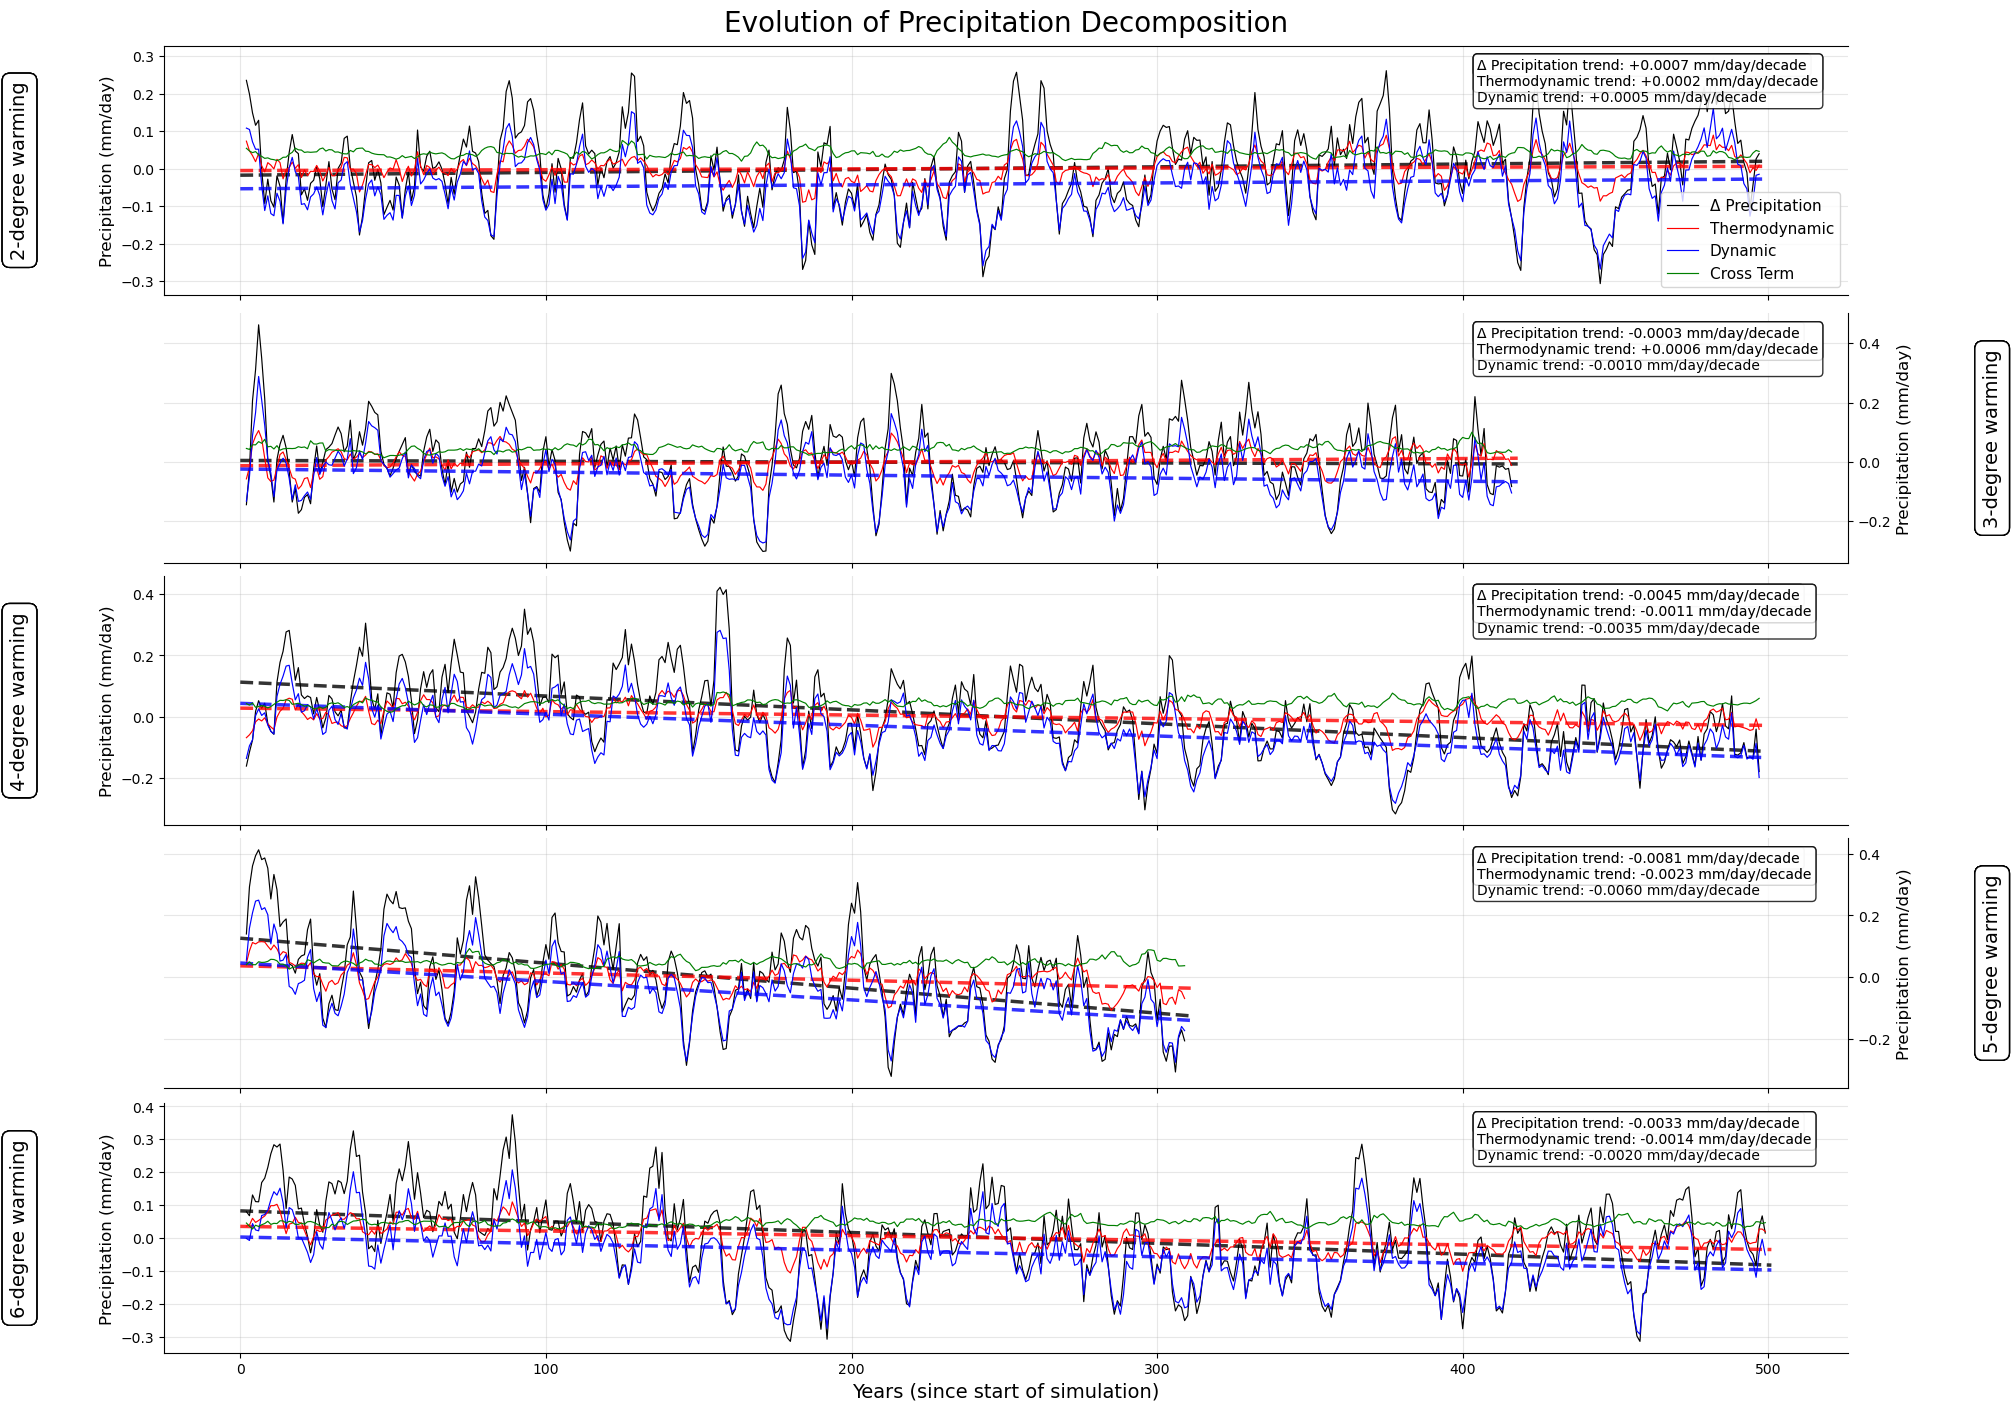

In [18]:
colour_list = ['black', 'red', 'blue', 'green']
trend_vals_store_dict = {scenario: {} for scenario in names}

save = True
save_path = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'
filename = f'{save_path}/decomposition_time_series.png'

decompose_time_series(avg_data, names, var_list, colour_list, trend_vals_store_dict)

In [18]:
trend_vals_store_dict[scenario]

{'delta_precip': np.float64(-0.003293032325831519),
 'thermodynamic': np.float64(-0.0014035145045554075),
 'dynamic': np.float64(-0.002000784387344819),
 'cross_term': np.float64(0.00011126655765810413)}

## Statistical Significance

### Student t-Test

In [17]:
def ttest_NO_bootstrap(data_scen, data_piCTL):
    n_scen = data_scen.shape[0]
    n_ctl = data_piCTL.shape[0]

    assert n_scen == n_ctl
    
    t_stat, p_value = ttest_ind(data_scen, data_piCTL, axis=0, equal_var=False)

    # Create an Xarray
    p_empirical_xr = xr.DataArray(p_value, dims=["plev", "latitude", 'longitude'],
                                  coords={"plev": data_scen["plev"],
                                          "latitude": data_scen["latitude"],
                                          "longitude": data_scen["longitude"]},
                                  name="p_value")

    # Assign a name to your DataArray
    p_empirical_xr.name = "p_value"

    # Convert it to a Dataset (NetCDF requires a Dataset format)
    ds = p_empirical_xr.to_dataset()    
    return ds

### Computation

In [18]:
var_significance = {scenario: {} for scenario in names}

for scenario in names:
    for variable in var_list:

        # Data
        data = avg_data[scenario][variable]
        y = data.values
        x = data['year'].values

        # Extract first and last 100 years
        y_first = y[:100]
        y_last = y[-100:]

        # Remove NaNs independently
        y_first = y_first[~np.isnan(y_first)]
        y_last = y_last[~np.isnan(y_last)]

        # Fit trends
        x_first = x[:100][~np.isnan(y[:100])]
        x_last = x[-100:][~np.isnan(y[-100:])]

        coeff_first = np.polyfit(x_first, y_first, 1)
        coeff_last = np.polyfit(x_last, y_last, 1)

        slope_first = coeff_first[0]
        slope_last  = coeff_last[0]

        # Student t-test on bias values
        t_stat, p_val = ttest_ind(y_first, y_last, equal_var=False)

        var_significance[scenario][variable] = {'slope_first': slope_first,
                                                'slope_last': slope_last,
                                                'p_value_mean_difference': p_val,
                                                'mean_difference_significant': p_val < 0.05}

In [19]:
var_significance[names[0]]

{'delta_precip': {'slope_first': np.float64(0.00023003024517803452),
  'slope_last': np.float64(0.0012667930335057678),
  'p_value_mean_difference': np.float64(0.781293261306094),
  'mean_difference_significant': np.False_},
 'thermodynamic': {'slope_first': np.float64(2.4195881963387737e-05),
  'slope_last': np.float64(0.00042665567732752877),
  'p_value_mean_difference': np.float64(0.9924776358602455),
  'mean_difference_significant': np.False_},
 'dynamic': {'slope_first': np.float64(0.000248534370256927),
  'slope_last': np.float64(0.0008209933206110748),
  'p_value_mean_difference': np.float64(0.7086507349586398),
  'mean_difference_significant': np.False_},
 'cross_term': {'slope_first': np.float64(-4.269998165220182e-05),
  'slope_last': np.float64(1.9144041929657336e-05),
  'p_value_mean_difference': np.float64(0.9040787853339411),
  'mean_difference_significant': np.False_}}

In [20]:
var_significance[names[1]]

{'delta_precip': {'slope_first': np.float64(0.00015220712787966724),
  'slope_last': np.float64(-0.0008218836452474533),
  'p_value_mean_difference': np.float64(0.49174039322405394),
  'mean_difference_significant': np.False_},
 'thermodynamic': {'slope_first': np.float64(0.0003756242681143293),
  'slope_last': np.float64(-7.62470978813865e-05),
  'p_value_mean_difference': np.float64(0.31014908591423695),
  'mean_difference_significant': np.False_},
 'dynamic': {'slope_first': np.float64(-5.416844629964987e-05),
  'slope_last': np.float64(-0.0007443497674776312),
  'p_value_mean_difference': np.float64(0.0900609527935683),
  'mean_difference_significant': np.False_},
 'cross_term': {'slope_first': np.float64(-0.0001692487060673128),
  'slope_last': np.float64(-1.286777785312724e-06),
  'p_value_mean_difference': np.float64(0.051575449902080156),
  'mean_difference_significant': np.False_}}

In [21]:
var_significance[names[2]]

{'delta_precip': {'slope_first': np.float64(0.0018696743947363655),
  'slope_last': np.float64(-0.00042403722517611196),
  'p_value_mean_difference': np.float64(2.1870340362005827e-06),
  'mean_difference_significant': np.True_},
 'thermodynamic': {'slope_first': np.float64(0.0008510915481838243),
  'slope_last': np.float64(-0.00022852011409733072),
  'p_value_mean_difference': np.float64(0.0002649571524533637),
  'mean_difference_significant': np.True_},
 'dynamic': {'slope_first': np.float64(0.0010555061674325118),
  'slope_last': np.float64(-0.0001386216118078263),
  'p_value_mean_difference': np.float64(2.3473531664732293e-07),
  'mean_difference_significant': np.True_},
 'cross_term': {'slope_first': np.float64(-3.6923330776952926e-05),
  'slope_last': np.float64(-5.6895498372361e-05),
  'p_value_mean_difference': np.float64(0.016755042827560376),
  'mean_difference_significant': np.True_}}

In [22]:
var_significance[names[3]]

{'delta_precip': {'slope_first': np.float64(-0.0019132691322973825),
  'slope_last': np.float64(-0.0008972201298803815),
  'p_value_mean_difference': np.float64(9.525772945163518e-06),
  'mean_difference_significant': np.True_},
 'thermodynamic': {'slope_first': np.float64(-0.0006722143688546191),
  'slope_last': np.float64(-0.0002811034013258928),
  'p_value_mean_difference': np.float64(1.1775389334151156e-05),
  'mean_difference_significant': np.True_},
 'dynamic': {'slope_first': np.float64(-0.001267201797191795),
  'slope_last': np.float64(-0.0007289295351602601),
  'p_value_mean_difference': np.float64(1.7384985507440145e-05),
  'mean_difference_significant': np.True_},
 'cross_term': {'slope_first': np.float64(2.6147028891670905e-05),
  'slope_last': np.float64(0.00011281282789047184),
  'p_value_mean_difference': np.float64(0.3335602064481935),
  'mean_difference_significant': np.False_}}

## Correlations (Pearson Coefficients)

In [30]:
from scipy.stats import pearsonr

correlations = {scenario: {} for scenario in names}

var_list_corr = ['thermodynamic', 'dynamic', 'cross_term']

for scenario in names:
    for variable in var_list_corr:
        x = avg_data[scenario]['delta_precip'].values.flatten()
        y = avg_data[scenario][variable].values.flatten()

        # Remove NaN values
        mask = np.isfinite(x) & np.isfinite(y)
    
        r, p = pearsonr(x[mask], y[mask])
        r_squared = r**2
        correlations[scenario][variable] = {'r': r, 'r**2': r_squared, 'p': p}

In [31]:
correlations[names[0]]

{'thermodynamic': {'r': np.float64(0.9082657677589625),
  'r**2': np.float64(0.8249467048827777),
  'p': np.float64(1.3935178810539244e-190)},
 'dynamic': {'r': np.float64(0.9864867604797825),
  'r**2': np.float64(0.9731561286018957),
  'p': np.float64(0.0)},
 'cross_term': {'r': np.float64(0.09969700145802679),
  'r**2': np.float64(0.009939492099721796),
  'p': np.float64(0.025795972265284475)}}

In [32]:
correlations[names[1]]

{'thermodynamic': {'r': np.float64(0.8784357541294153),
  'r**2': np.float64(0.7716493741329146),
  'p': np.float64(8.244332093761086e-136)},
 'dynamic': {'r': np.float64(0.9802359036379893),
  'r**2': np.float64(0.9608624267809854),
  'p': np.float64(1.432404131887593e-295)},
 'cross_term': {'r': np.float64(-0.037403752571836035),
  'r**2': np.float64(0.0013990407064551308),
  'p': np.float64(0.44509628646734056)}}

In [33]:
correlations[names[2]]

{'thermodynamic': {'r': np.float64(0.879703259156117),
  'r**2': np.float64(0.7738778241698944),
  'p': np.float64(6.917728656190793e-163)},
 'dynamic': {'r': np.float64(0.9827260273107832),
  'r**2': np.float64(0.9657504447540342),
  'p': np.float64(0.0)},
 'cross_term': {'r': np.float64(0.08707405491037358),
  'r**2': np.float64(0.007581891038534753),
  'p': np.float64(0.0516716799576764)}}

In [34]:
correlations[names[3]]

{'thermodynamic': {'r': np.float64(0.8701571017625525),
  'r**2': np.float64(0.757173381747805),
  'p': np.float64(2.733954240559788e-97)},
 'dynamic': {'r': np.float64(0.9847014816821811),
  'r**2': np.float64(0.9696370080270827),
  'p': np.float64(2.666664304703241e-237)},
 'cross_term': {'r': np.float64(0.06596866743368743),
  'r**2': np.float64(0.004351865082976452),
  'p': np.float64(0.24530537394286284)}}

In [35]:
correlations[names[4]]

{'thermodynamic': {'r': np.float64(0.853437202777118),
  'r**2': np.float64(0.7283550590840316),
  'p': np.float64(1.3217507913993488e-143)},
 'dynamic': {'r': np.float64(0.9814825993875047),
  'r**2': np.float64(0.963308092900453),
  'p': np.float64(0.0)},
 'cross_term': {'r': np.float64(-0.02857027532060382),
  'r**2': np.float64(0.0008162606318951037),
  'p': np.float64(0.5230429595749659)}}